In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import util
import experiment_utils
from my_datasets import get_dataset

# Data
Let's load our MNIST and TinyStories datasets.

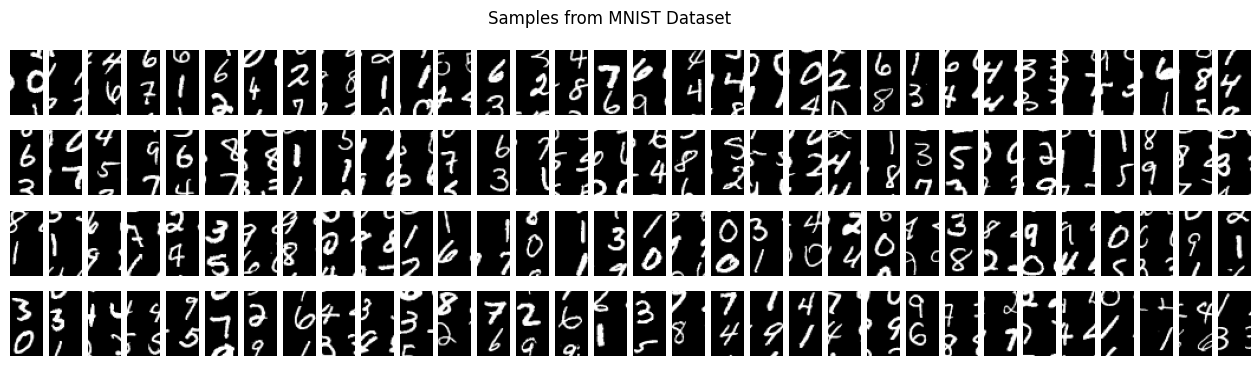

In [2]:
tokenizer, ds_train, ds_test = get_dataset("mnist")

batch = ds_train.sample_batch(128, 28*28*2)
x = batch['x']
imgs = tokenizer.decode(x.cpu().numpy())
plt.figure(figsize=(16, 4))
for i in range(128):
    plt.subplot(4, 32, i+1)
    plt.imshow(imgs[i], cmap='gray', vmin=0, vmax=255); plt.axis('off')
plt.suptitle("Samples from MNIST Dataset")
plt.show()

In [3]:
from IPython.display import display
tokenizer, ds_train, ds_test = get_dataset("tinystories")
batch = ds_train.sample_batch(8, 256)
x = batch['x']
txt = tokenizer.decode(x.cpu().numpy())
print("Samples from TinyStories Dataset\n\n")
for i in range(8):
    display(txt[i])
    print()

Samples from TinyStories Dataset




'at picking up new things.\n\nOne day, she wanted to feed herself so she learnt how to use a dish! She was so proud of herself.\n\nShe got her favorite food and put it on the dish. She was so excited to eat it.\n\nShe took the dish and carefully fed herself. It w'

'ed up. It was a big messy mess! Mommy and Johnny had to pull the plug and start all over again. \n\nJohnny knew to be more careful and clapped his hands in excitement to start again. He watched and listened as Mommy certainly put the mixer back together. It '

' The flower started to bloom and it was very happy. The little girl was happy too. She said, "Just like this flower, we all have something special inside us. We just need someone to help us bloom."\n\nThe little girl gave the flower a necklace with pretty je'

'nt on it to make him feel strong and reliable like his mom.Once upon a time there was a number of friends who wanted to find a place to play. They looked everywhere, up, down and all around but couldn\'t find a place.\n\n"Let\'s go to the park," said one of th'

'spend our coin wisely and safely."\n\nTheir mom smiled and said, "That\'s good. Now, how about some cookies and milk?"\n\nTom and Lily cheered and followed their mom to the kitchen. They forgot about the lollipop and the dog. They were happy to have their mom a'

'iny. Lucy liked the leaf a lot.\n\nLucy took the leaf home and showed it to her mom. Her mom said, "What a beautiful leaf!" Lucy smiled and put the leaf in her room. She looked at the leaf every day and felt happy.Once upon a time, there was a creative girl '

'led into the branches.\n\nThe raven sighed with relief and faced the cold facts: he had made the right decision to fly and he did not regret it.Once upon a time there was a little girl named Daisy. One day Daisy went outside to play. As she skipped and laugh'

"felt much better. But then, a big sandstorm came and they got lost. They couldn't find their way back home. They were very scared and needed help. Sadly, they were never found and never made it back home.Once upon a time, there was a little girl named Lily"

# Running SMT and DMT

## Run Configurations

Now let's set up the configurations for our SMT and DMT scripts.
`experiment_utils.create_commands` is a simple command to turn dataclass configurations to python commands we can run.

Note that we want to run SMT pretraining and then DMT finetuning.
This is done by matching the DMT load_rnn_path and load_teacher_path to SMT save_dir.

In [4]:
from train_smt import Config, TeacherConfig, RNNConfig, SMTConfig

cfg_smt_mnist = Config(seed=0, dataset='mnist', n_iters=150000, log_every=1000, ckpt_every=None, save_dir='./runs/smt_mnist_0/', load_rnn_path=None, load_teacher_path=None,
                       rnn=RNNConfig(vocab_size=256, mem_size=4096, mem_tokens=16, mem_rms_norm=True, mem_fsq=None, d_model=256, rnn_depth=8, decoder_depth=4, n_heads=8, rotary_pos_emb=True, use_rmsnorm=True),
                       teacher=TeacherConfig(vocab_size=256, mem_size=4096, mem_tokens=16, mem_rms_norm=True, mem_fsq=None, d_model=256, encoder_depth=8, decoder_depth=4, n_heads=8, rotary_pos_emb=True, use_rmsnorm=True),
                       lr=0.0003, lr_schedule='warmup_constant', weight_decay=0.01, adam_betas=(0.9, 0.95), batch_size=128, grad_accum_steps=1, clip_grad_norm=1.0,
                       smt=SMTConfig(T=320, Tc=256, Tf=64, gamma=1.0, coef_dec=1.0, coef_dyn=0.1, coef_unif=0.001, unif_over_tokens=True, detach_rnn=False, hot_rnn=True, hot_teacher=True)
                      )

cfg_smt_tinystories = Config(seed=0, dataset='tinystories', n_iters=150000, log_every=1000, ckpt_every=None, save_dir='./runs/smt_tinystories_0/', load_rnn_path=None, load_teacher_path=None,
                             rnn=RNNConfig(vocab_size=256, mem_size=4096, mem_tokens=16, mem_rms_norm=True, mem_fsq=None, d_model=256, rnn_depth=8, decoder_depth=4, n_heads=8, rotary_pos_emb=True, use_rmsnorm=True),
                             teacher=TeacherConfig(vocab_size=256, mem_size=4096, mem_tokens=16, mem_rms_norm=True, mem_fsq=None, d_model=256, encoder_depth=8, decoder_depth=4, n_heads=8, rotary_pos_emb=True, use_rmsnorm=True),
                             lr=0.0003, lr_schedule='warmup_constant', weight_decay=0.01, adam_betas=(0.9, 0.95), batch_size=128, grad_accum_steps=1, clip_grad_norm=1.0,
                             smt=SMTConfig(T=320, Tc=256, Tf=64, gamma=1.0, coef_dec=1.0, coef_dyn=0.1, coef_unif=0.001, unif_over_tokens=True, detach_rnn=False, hot_rnn=True, hot_teacher=True)
                            )

commands = experiment_utils.create_commands([cfg_smt_mnist, cfg_smt_tinystories], prefix="python train_smt.py")
for c in commands: print(c, "\n")

python train_smt.py --seed=0 --dataset="mnist"       --n_iters=150000 --log_every=1000 --ckpt_every=None --save_dir="./runs/smt_mnist_0/"       --load_rnn_path=None --load_teacher_path=None --rnn.vocab_size=256 --rnn.mem_size=4096 --rnn.mem_tokens=16 --rnn.mem_rms_norm=True --rnn.mem_fsq=None --rnn.d_model=256 --rnn.rnn_depth=8 --rnn.decoder_depth=4 --rnn.n_heads=8 --rnn.rotary_pos_emb=True --rnn.use_rmsnorm=True --teacher.vocab_size=256 --teacher.mem_size=4096 --teacher.mem_tokens=16 --teacher.mem_rms_norm=True --teacher.mem_fsq=None --teacher.d_model=256 --teacher.encoder_depth=8 --teacher.decoder_depth=4 --teacher.n_heads=8 --teacher.rotary_pos_emb=True --teacher.use_rmsnorm=True --lr=0.0003 --lr_schedule="warmup_constant" --weight_decay=0.01 --adam_betas 0.9 0.95 --batch_size=128 --grad_accum_steps=1 --clip_grad_norm=1.0 --smt.T=320 --smt.Tc=256 --smt.Tf=64 --smt.gamma=1.0 --smt.coef_dec=1.0 --smt.coef_dyn=0.1 --smt.coef_unif=0.001 --smt.unif_over_tokens=True --smt.detach_rnn=False

In [5]:
from train_dmt import Config, TeacherConfig, RNNConfig, DMTConfig

cfg_dmt_mnist = Config(seed=0, dataset='mnist', n_iters=1500, log_every=10, ckpt_every=300, save_dir='./runs/smt_mnist_0//ft_dmt_256', load_rnn_path='./runs/smt_mnist_0//rnn.pkl', load_teacher_path='./runs/smt_mnist_0//teacher.pkl',
                       rnn=RNNConfig(vocab_size=256, mem_size=4096, mem_tokens=16, mem_rms_norm=True, mem_fsq=None, d_model=256, rnn_depth=8, decoder_depth=4, n_heads=8, rotary_pos_emb=True, use_rmsnorm=True),
                       teacher=TeacherConfig(vocab_size=256, mem_size=4096, mem_tokens=16, mem_rms_norm=True, mem_fsq=None, d_model=256, encoder_depth=8, decoder_depth=4, n_heads=8, rotary_pos_emb=True, use_rmsnorm=True),
                       lr=3e-05, lr_schedule='warmup_cosine', weight_decay=0.01, adam_betas=(0.9, 0.95), batch_size=32, clip_grad_norm=1.0,
                       dmt=DMTConfig(T=576, Td=256, Tc=256, Tf=64, k=16, coef_dec=1.0, coef_dyn=10.0, coef_unif=0.01, coef_readout=1.0, detach_readout=True, detach_rnn=False, hot_rnn=True, hot_teacher_encoder=False, hot_teacher_decoder=False)
                      )

cfg_dmt_tinystories = Config(seed=0, dataset='tinystories', n_iters=1500, log_every=10, ckpt_every=300, save_dir='./runs/smt_tinystories_0//ft_dmt_256', load_rnn_path='./runs/smt_tinystories_0//rnn.pkl', load_teacher_path='./runs/smt_tinystories_0//teacher.pkl',
                             rnn=RNNConfig(vocab_size=256, mem_size=4096, mem_tokens=16, mem_rms_norm=True, mem_fsq=None, d_model=256, rnn_depth=8, decoder_depth=4, n_heads=8, rotary_pos_emb=True, use_rmsnorm=True),
                             teacher=TeacherConfig(vocab_size=256, mem_size=4096, mem_tokens=16, mem_rms_norm=True, mem_fsq=None, d_model=256, encoder_depth=8, decoder_depth=4, n_heads=8, rotary_pos_emb=True, use_rmsnorm=True),
                             lr=3e-05, lr_schedule='warmup_cosine', weight_decay=0.01, adam_betas=(0.9, 0.95), batch_size=32, clip_grad_norm=1.0,
                             dmt=DMTConfig(T=576, Td=256, Tc=256, Tf=64, k=16, coef_dec=1.0, coef_dyn=10.0, coef_unif=0.01, coef_readout=1.0, detach_readout=True, detach_rnn=False, hot_rnn=True, hot_teacher_encoder=False, hot_teacher_decoder=False)
                            )

commands = experiment_utils.create_commands([cfg_dmt_mnist, cfg_dmt_tinystories], prefix="python train_dmt.py")
for c in commands: print(c, "\n")



python train_dmt.py --seed=0 --dataset="mnist"       --n_iters=1500 --log_every=10 --ckpt_every=300 --save_dir="./runs/smt_mnist_0//ft_dmt_256"       --load_rnn_path="./runs/smt_mnist_0//rnn.pkl"       --load_teacher_path="./runs/smt_mnist_0//teacher.pkl"       --rnn.vocab_size=256 --rnn.mem_size=4096 --rnn.mem_tokens=16 --rnn.mem_rms_norm=True --rnn.mem_fsq=None --rnn.d_model=256 --rnn.rnn_depth=8 --rnn.decoder_depth=4 --rnn.n_heads=8 --rnn.rotary_pos_emb=True --rnn.use_rmsnorm=True --teacher.vocab_size=256 --teacher.mem_size=4096 --teacher.mem_tokens=16 --teacher.mem_rms_norm=True --teacher.mem_fsq=None --teacher.d_model=256 --teacher.encoder_depth=8 --teacher.decoder_depth=4 --teacher.n_heads=8 --teacher.rotary_pos_emb=True --teacher.use_rmsnorm=True --lr=3e-05 --lr_schedule="warmup_cosine" --weight_decay=0.01 --adam_betas 0.9 0.95 --batch_size=32 --clip_grad_norm=1.0 --dmt.T=576 --dmt.Td=256 --dmt.Tc=256 --dmt.Tf=64 --dmt.k=16 --dmt.coef_dec=1.0 --dmt.coef_dyn=10.0 --dmt.coef_unif=

## Launching Runs
Now go ahead a run these python commands that were the outputs from above.

Each SMT run should take around ~9 hours on a single H200 GPU.\
Each DMT run should take around ~7 hours on a single H200 GPU.

The DMT run uses wayyy less total FLOPs than the SMT run, but it is not easy to parallelize the RNN rollout, so it ends up taking nearly as long.


For SMT on MNIST:
```python
python train_smt.py --seed=0 --dataset="mnist"       --n_iters=150000 --log_every=1000 --ckpt_every=None --save_dir="./runs/smt_mnist_0/"       --load_rnn_path=None --load_teacher_path=None --rnn.vocab_size=256 --rnn.mem_size=4096 --rnn.mem_tokens=16 --rnn.mem_rms_norm=True --rnn.mem_fsq=None --rnn.d_model=256 --rnn.rnn_depth=8 --rnn.decoder_depth=4 --rnn.n_heads=8 --rnn.rotary_pos_emb=True --rnn.use_rmsnorm=True --teacher.vocab_size=256 --teacher.mem_size=4096 --teacher.mem_tokens=16 --teacher.mem_rms_norm=True --teacher.mem_fsq=None --teacher.d_model=256 --teacher.encoder_depth=8 --teacher.decoder_depth=4 --teacher.n_heads=8 --teacher.rotary_pos_emb=True --teacher.use_rmsnorm=True --lr=0.0003 --lr_schedule="warmup_constant" --weight_decay=0.01 --adam_betas 0.9 0.95 --batch_size=128 --grad_accum_steps=1 --clip_grad_norm=1.0 --smt.T=320 --smt.Tc=256 --smt.Tf=64 --smt.gamma=1.0 --smt.coef_dec=1.0 --smt.coef_dyn=0.1 --smt.coef_unif=0.001 --smt.unif_over_tokens=True --smt.detach_rnn=False --smt.hot_rnn=True --smt.hot_teacher=True 
```

For SMT on TinyStories:
```python
python train_smt.py --seed=0 --dataset="tinystories" --n_iters=150000 --log_every=1000 --ckpt_every=None --save_dir="./runs/smt_tinystories_0/" --load_rnn_path=None --load_teacher_path=None --rnn.vocab_size=256 --rnn.mem_size=4096 --rnn.mem_tokens=16 --rnn.mem_rms_norm=True --rnn.mem_fsq=None --rnn.d_model=256 --rnn.rnn_depth=8 --rnn.decoder_depth=4 --rnn.n_heads=8 --rnn.rotary_pos_emb=True --rnn.use_rmsnorm=True --teacher.vocab_size=256 --teacher.mem_size=4096 --teacher.mem_tokens=16 --teacher.mem_rms_norm=True --teacher.mem_fsq=None --teacher.d_model=256 --teacher.encoder_depth=8 --teacher.decoder_depth=4 --teacher.n_heads=8 --teacher.rotary_pos_emb=True --teacher.use_rmsnorm=True --lr=0.0003 --lr_schedule="warmup_constant" --weight_decay=0.01 --adam_betas 0.9 0.95 --batch_size=128 --grad_accum_steps=1 --clip_grad_norm=1.0 --smt.T=320 --smt.Tc=256 --smt.Tf=64 --smt.gamma=1.0 --smt.coef_dec=1.0 --smt.coef_dyn=0.1 --smt.coef_unif=0.001 --smt.unif_over_tokens=True --smt.detach_rnn=False --smt.hot_rnn=True --smt.hot_teacher=True 
```

For DMT on MNIST:
```python
python train_dmt.py --seed=0 --dataset="mnist"       --n_iters=1500 --log_every=10 --ckpt_every=300 --save_dir="./runs/smt_mnist_0//ft_dmt_256"       --load_rnn_path="./runs/smt_mnist_0//rnn.pkl"       --load_teacher_path="./runs/smt_mnist_0//teacher.pkl"       --rnn.vocab_size=256 --rnn.mem_size=4096 --rnn.mem_tokens=16 --rnn.mem_rms_norm=True --rnn.mem_fsq=None --rnn.d_model=256 --rnn.rnn_depth=8 --rnn.decoder_depth=4 --rnn.n_heads=8 --rnn.rotary_pos_emb=True --rnn.use_rmsnorm=True --teacher.vocab_size=256 --teacher.mem_size=4096 --teacher.mem_tokens=16 --teacher.mem_rms_norm=True --teacher.mem_fsq=None --teacher.d_model=256 --teacher.encoder_depth=8 --teacher.decoder_depth=4 --teacher.n_heads=8 --teacher.rotary_pos_emb=True --teacher.use_rmsnorm=True --lr=3e-05 --lr_schedule="warmup_cosine" --weight_decay=0.01 --adam_betas 0.9 0.95 --batch_size=32 --clip_grad_norm=1.0 --dmt.T=576 --dmt.Td=256 --dmt.Tc=256 --dmt.Tf=64 --dmt.k=16 --dmt.coef_dec=1.0 --dmt.coef_dyn=10.0 --dmt.coef_unif=0.01 --dmt.coef_readout=1.0 --dmt.detach_readout=True --dmt.detach_rnn=False --dmt.hot_rnn=True --dmt.hot_teacher_encoder=False --dmt.hot_teacher_decoder=False 
```


For DMT on TinyStories:
```python
python train_dmt.py --seed=0 --dataset="tinystories" --n_iters=1500 --log_every=10 --ckpt_every=300 --save_dir="./runs/smt_tinystories_0//ft_dmt_256" --load_rnn_path="./runs/smt_tinystories_0//rnn.pkl" --load_teacher_path="./runs/smt_tinystories_0//teacher.pkl" --rnn.vocab_size=256 --rnn.mem_size=4096 --rnn.mem_tokens=16 --rnn.mem_rms_norm=True --rnn.mem_fsq=None --rnn.d_model=256 --rnn.rnn_depth=8 --rnn.decoder_depth=4 --rnn.n_heads=8 --rnn.rotary_pos_emb=True --rnn.use_rmsnorm=True --teacher.vocab_size=256 --teacher.mem_size=4096 --teacher.mem_tokens=16 --teacher.mem_rms_norm=True --teacher.mem_fsq=None --teacher.d_model=256 --teacher.encoder_depth=8 --teacher.decoder_depth=4 --teacher.n_heads=8 --teacher.rotary_pos_emb=True --teacher.use_rmsnorm=True --lr=3e-05 --lr_schedule="warmup_cosine" --weight_decay=0.01 --adam_betas 0.9 0.95 --batch_size=32 --clip_grad_norm=1.0 --dmt.T=576 --dmt.Td=256 --dmt.Tc=256 --dmt.Tf=64 --dmt.k=16 --dmt.coef_dec=1.0 --dmt.coef_dyn=10.0 --dmt.coef_unif=0.01 --dmt.coef_readout=1.0 --dmt.detach_readout=True --dmt.detach_rnn=False --dmt.hot_rnn=True --dmt.hot_teacher_encoder=False --dmt.hot_teacher_decoder=False 
```




# Analyzing the Results

Now that the runs are down, let's run RNN inference!


The `write_with_teacher_rnn` function uses the teacher encoder to embed the first [read_len] tokens into an initial memory state, and then unrolls the RNN for [write_len] tokens.

In [6]:
cfg = cfg_dmt_mnist
print(cfg.dataset)

rnn = util.load_pkl(cfg.save_dir, "rnn").cuda()
teacher = util.load_pkl(cfg.save_dir, "teacher").cuda()

tokenizer, ds_train, ds_test = get_dataset(cfg.dataset)
batch = ds_test.sample_batch(128, 256)
x = batch['x'].cuda().long()

from model import write_with_teacher_rnn
w = write_with_teacher_rnn(rnn, teacher, x, read_len=256, write_len=28*28*2, pbar=True)

mnist


  0%|          | 0/1568 [00:00<?, ?it/s]

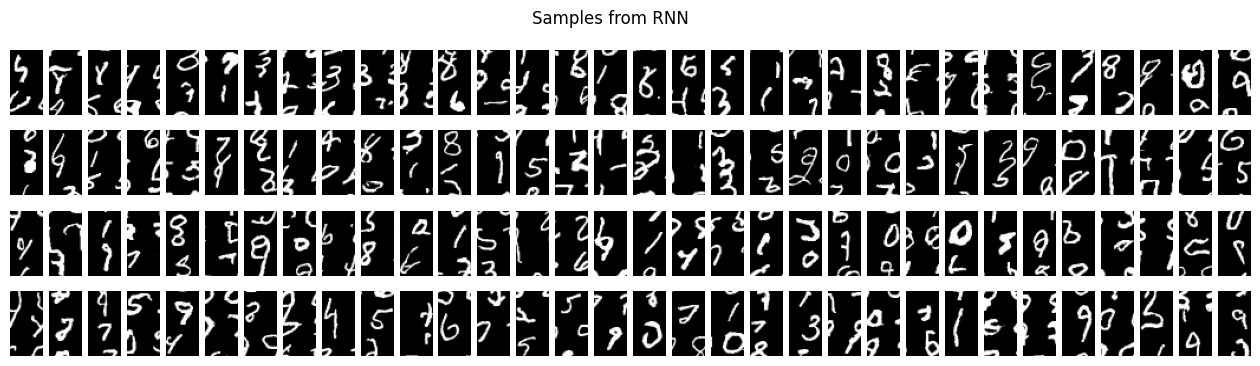

In [7]:
imgs = tokenizer.decode(w['x_write'].cpu().numpy())
plt.figure(figsize=(16, 4))
for i in range(128):
    plt.subplot(4, 32, i+1)
    plt.imshow(imgs[i], cmap='gray', vmin=0, vmax=255); plt.axis('off')
plt.suptitle("Samples from RNN")
plt.show()


In [8]:
cfg = cfg_dmt_tinystories
print(cfg.dataset)

rnn = util.load_pkl(cfg.save_dir, "rnn").cuda()
teacher = util.load_pkl(cfg.save_dir, "teacher").cuda()

tokenizer, ds_train, ds_test = get_dataset(cfg.dataset)
batch = ds_test.sample_batch(128, 256)
x = batch['x'].cuda().long()

from model import write_with_teacher_rnn
w = write_with_teacher_rnn(rnn, teacher, x, read_len=256, write_len=1024, pbar=True)

tinystories


  0%|          | 0/1024 [00:00<?, ?it/s]

In [9]:
from IPython.display import display
txt = tokenizer.decode(w['x_write'].cpu().numpy())
print("Samples from RNN\n\n")
for i in range(8):
    display(txt[i])
    print()

Samples from RNN




'enjoyed the sunny day.Once upon a time, there was a man who had a wonderful map. He often hopped his map into tiny room and his dad, for many mighting go away.\n\nThe magic made him feel excited at a mouse. He shivered and his hands, even lots of things gracefully. He wore them around the room and made a funny room. His mom started to laugh and play. He had a very lot of fun being about his toys.\n\nThe end.Max was excited. Today, he was polite and wept.\n"Whanning we do?" and his mum.\n"We\'ll show everyone who has done you" said mom.\n\n"Nowever!" said mum.\n\n"No! But we need to sell our pets. We are dangerous outside, it can make us happy. We are patient now," said Mom.\n\n"No, that we have to buy something else. We should share them," Moll said.\n\nMolly\'s mom saw them. She looked very angry and had a smelly picture. They looked for something that had cut in the garden. A bracelet in Molly had seen a bee maggine on the ground.\n\nMolly said, "Why? Oh. Breams are big and beautifu

'explore. He saw Tommy standing deal and listened carelas her ticket.\n\n"Wow, look at that journal, Look little twinkler!" he said.\n\nTommy nodded near the journal and investured how good he loved an open place. He had a great party show around him who would always create pretendes. He was so happy.Once there was a robot named Verici. He was very lazy and always wanted to join the river. One day Vericise saw a very fan bench and ran inside. He was curious and wanted to explore the river.\n\nThe river was ready to explore the river. But then, the raven realized that he had to hold the lifeboard tight. He took it and swam off, and he had so much fun! \n\nWhen the red ride, the furry river was now strong than the whole rich river.\n\nThe magic remembers as how wid excited he could, he thoughten to rot like him medicined too!One day, Jerry saw something dry. He saw a cristle. It was made of sbide! It had color and a lot of leaves and two colors. The sky was colorful and round. The silly 

't a little bird inside. The wand began to make a special moon, but not instead.\n\nJulie smiled back and whispered, "That\'s something nice". Then she knew that the wand was a thoughtful one. It was safe that Jack\'s wand was bigger leaves. Jack knew it was the perfect gift for his little mission. He continued walking, exploring in the house, admiring all the wonderful wizards.John was outside happy. Nice day he just stood very sleeping. Then he opened the drink. He did not see the beef in the grass. \nThe been smiled and jumped in wide. He smiled with delight and the bees were round that it ran all around the the view. He espeat himself while giving up his adventure that partains he found the perfect speed across the village.\n\nWith a lot of luck, Joe picked up the jewel\'s police! He was so proud of his special piece with his work. He smiled and was so proud of himself for finding it. \n\nThe moral of the story is to forgive that we do. Even if things get surprised, you can buy rec

'went to bed. They closed their eyes and faced them. They dreamed of exploring the distant place.Ben likes to play hockey. He has a big red family on his waist. He pretends to be nice and kind. He has a big slew uniform solip with his silk door.\n\nOne day, he goes to the big park. He says his cousin was a parrot. He thinks that Ben is a funny parrot too. Ben thought it is so good. He thinks she is an original parrot.\n\nHe puts on his favorite card and bites it. Ben feels envious. He thinks maybe he is in a bad parrot. He thinks that being silly and naughty and shiny. He wants to make the paro!\n\nMia follows Tom to Tom. She sees that Tom is not her power. He says he lost him. He thinks he is being greedy and shy. He smiles and tries to pet Tom and Sue.\n\n"Mom, what? Tom, what is the parade?" Tom says.\n\n"It is a parade. Can you teach me some songs?" Tom asks.\n\n"Supeti, no, do we can\'t. Maybe look very silly to his hand. Do you like paina?"\n\nTom shows his sad face. He makes a b

'things, It is important to never buy anything up. Peter was so excited that it loves it.\n\nBut then Peter got upset and said: It\'s not worth kind he\'s fair. I should not if you make a mess." He looked a behind a tree and smiled. He put the teeth back in tight, looking at him again, so he got back to it.\n\nHe wanted and the torn stopped playing, but he didn\'t give up. He said a lesson that day was much better to visit his, and might leave his way.Ger was three yawning on his vest in the lab. It was very pretty. He closed their eyes and kept inside.\n\nWhen he was looking out his yard, he couldn\'t find answeed an old pond. He called out "Hello Green. I\'ve so late!" Geren opened the pond and recognized the pond. He watched with the pond too. He was having so much fun! He could not stop the pond. It packed his hands on water and it blew all over and gave him a big hug. What was the real next day? \n\nHis mom and Dad ran to the pond and got the delicious treat to him. Then they spli

's if they could make it together.\n\nThe whale thinks it is curious. It wants to hear sound like a whale. It meets a small house who thinks that sounds of lense. It says they are soft and colorful. It says it is a whistling door.\n\nThey go inside and look inside. They open the door and see more piles. There are more worms and pretty and brightes. They cannot find treasures and children. They eat the door in a secret with the flavor. They see many people who are angry.\n\n"Hello, kids," dad says. He is angry to Tom and Mia. "I have chosen for you. Those is for you. I am smaller lions. I will be more brave. And I will not hurt you. They are here."\n\nTom and Lily cry. They look at the man. He sees the animals again. They are sorry.\n\n"I am sorry, kids. I want to be a squirrel. Can I see a purple animal?" Sara asks.\n\n"No, Sara, you can\'t have a purple purple. Mom keeps watching animals," Mom says.\n\nSara and Tom are happy. They do not move and purple. They look at the hill. It does

'a time, there was a little boy named Timmy. He loved to play with his toys and cars on the floor. One day, Timmy\'s mom bought him a big car. The car was hard and it had a wheel on the wall. Timmy was so happy and happy.\n\nBut when Timmy came back to the car, his mom bought him a big switch. It was a swing. Timmy opened the switch and slid on it. He laughed and felt happy. He was having so much fun.Once upon a time, there was a battery snipper. The snowman was mighty and cold but no one was so normal. The proud battery thought of a plan to look, because it had too much now. The bunny tried and played until it broke! The butterfly felt sad and didn\'t know what to do. The next day, a baby came and saw the bad bug. The bug chased him and tried to get hid behind it and decided to hide and see who the bug was still there. The bug said, "Hello, little bug. I helped you find my thermometer  to find your help. Friends need to hide, and not hide there, even though we done it." The brave bug 

'an at the box. It\'s silly. I won\'t try to sit down."\n\nHis brother smiled. He said, "Sure, Timmy. I forgive you, but you want to see what book you did. Maybe I can fix your room. It will be glue."\n\nThe spoon was not too bad. It just slipped on the floors. Timmy felt bad. He also understood Lily and Timmy. They were bossy. They shared and talked a lot. They started to quarrel.\n\nLily heard Tom was playing. She felt a good helper. She learned that making circles laugh and smart. She did not exit them. She did not know what they was safe. She helped the squirrel and Lily go for a while. She told Tom to be careful and not run away. She told them what he had and they could show him. She said they had to finish being respectful.\n\nTom and Lily nodded. They got sad and sad. They wanted to play with the dog. But they learned a lesson.Tom and Anna are playing in the garden. They look for blue and flowers. They have red brown round wings and two birds. They want to fly the ground.\n\nBut